In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:

YAML_DIR = os.environ.get("YAML_DIR",'./weights')

yaml_content="""
path: ./data/dataset/..........
train: train/images
val: test/images

names:
    0: tumor
"""

with open(os.path.join(YAML_DIR,'data.yaml'),'w') as f:
    f.write(yaml_content)

In [ ]:
from ultralytics import YOLO


model = YOLO('yolov8n.pt')
metrics = model.train(data=os.path.join(YAML_DIR,'data.yaml'),epochs=75,imgsz=512)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=No

In [37]:
result = model.predict("/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/train/no_tumor/brisc2025_train_02479_no_ax_t1.jpg",conf=0.5)



image 1/1 /kaggle/input/datasets/briscdataset/brisc2025/brisc2025/classification_task/train/no_tumor/brisc2025_train_02479_no_ax_t1.jpg: 512x320 (no detections), 9.6ms
Speed: 1.5ms preprocess, 9.6ms inference, 0.9ms postprocess per image at shape (1, 3, 512, 320)


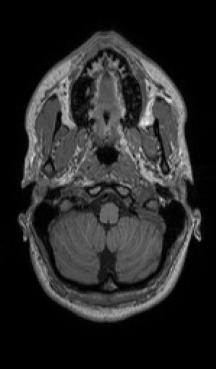

In [38]:
result[0].show()